In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    SBEEDSolver,
    DiscreteMDPSpec,
    RBFStateFeatures,
    RBFStateActionFeatures,
    TabularStateFeatures,
    SBEEDEvaluator,
)

/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3grid

In [2]:
def plot_grid_with_rbf(
    grid_size,
    centers,
    variance,
    values=None,
    policy=None,
    goal_grid=None,
    pit_grid=None,
    wall_states=None,
    terminal_states=None,
    title="Grid World with RBF Centers",
):
    """
    Plot a square grid with optional values, policy arrows, RBF centers, and RBF radius.
    Preserves original styling while adding robust support for walls and pits.
    """
    centers = torch.as_tensor(centers, dtype=torch.float64)

    if centers.ndim != 2 or centers.shape[1] != 2:
        raise ValueError("centers must have shape [K, 2] as normalized [row, col] coordinates")

    variance = torch.as_tensor(variance, dtype=torch.float64).reshape(-1)
    if variance.numel() == 1:
        variance = variance.repeat(centers.shape[0])
    if variance.numel() != centers.shape[0]:
        raise ValueError("variance must be scalar or have one value per center")

    radius = torch.sqrt(variance)

    N = grid_size * grid_size
    
    # Consistency: Ensure these are all sets for the 'in' checks
    def to_set(x):
        if x is None: return set()
        if isinstance(x, (int, float, np.integer)): return {int(x)}
        return set(int(s) for s in x)

    goals = to_set(goal_grid)
    pits = to_set(pit_grid)
    walls = to_set(wall_states)
    terminals = to_set(terminal_states) | goals | pits

    def state_to_pos(s):
        return divmod(int(s), grid_size)

    fig, ax = plt.subplots(figsize=(8, 8))

    grid = np.zeros((grid_size, grid_size))

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values)
        grid = values.reshape(grid_size, grid_size)

    # REVERTED: Original background logic
    ax.imshow(
        grid,
        cmap="viridis",
        origin="upper",
        alpha=0.3 if values is not None else 0.1,
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)

    if policy is not None and hasattr(policy, "detach"):
        policy = policy.detach().cpu().numpy()

    for s in range(N):
        r, c = state_to_pos(s)

        # REVERTED: Original rectangle and text logic
        if s in goals:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="green", alpha=0.5))
            ax.text(c, r, "GOAL", ha="center", va="center", fontweight="bold")

        elif s in pits:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="red", alpha=0.5))
            ax.text(c, r, "PIT", ha="center", va="center", fontweight="bold", color="white")

        elif s in walls:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="gray"))
            ax.text(c, r, "WALL", ha="center", va="center", fontweight="bold", color="white")

        else:
            ax.text(c - 0.4, r - 0.4, str(s), fontsize=8, color="gray")
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha="center", va="center", fontsize=10)

        # Draw Policy Arrows (excluding terminals and walls)
        if policy is not None and s not in terminals and s not in walls:
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]

            dx, dy = 0.0, 0.0
            if best_action == 0:      dy = -0.3
            elif best_action == 1:    dy = 0.3
            elif best_action == 2:    dx = -0.3
            elif best_action == 3:    dx = 0.3

            ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc="black", ec="black")

    # REVERTED: Original RBF Center styling
    for i, center in enumerate(centers):
        row_norm, col_norm = center.tolist()

        r = row_norm * (grid_size - 1)
        c = col_norm * (grid_size - 1)
        radius_cells = radius[i].item() * (grid_size - 1)

        circle = plt.Circle(
            (c, r),
            radius_cells,
            color="tab:red",
            fill=False,
            linewidth=2,
            alpha=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(c, r, color="tab:red", marker="x", s=120, linewidths=3)
        ax.text(
            c,
            r + 0.18,
            f"c{i}",
            ha="center",
            va="bottom",
            color="tab:red",
            fontweight="bold",
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    plt.show()

In [53]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:
        r = max(0, r - 1)
    elif a == 1:
        r = min(2, r + 1)
    elif a == 2:
        c = max(0, c - 1)
    elif a == 3:
        c = min(2, c + 1)

    return to_s(r, c)


state_coords = torch.tensor(
    [[r / 2.0, c / 2.0] for r in range(3) for c in range(3)],
    dtype=torch.float64,
)

centers = torch.tensor(
    [
        [0.25, 0.25],  # start corner
        [0.25, 0.75],  # top-right
        [0.75, 0.25],  # bottom-left
        [0.75, 0.75],  # goal
    ],
    dtype=torch.float64,
)

# centers = state_coords.clone()

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.75,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)


def reward_fn(s, a, sp):
    return 1.0 if int(sp) == goal_grid else -0.1

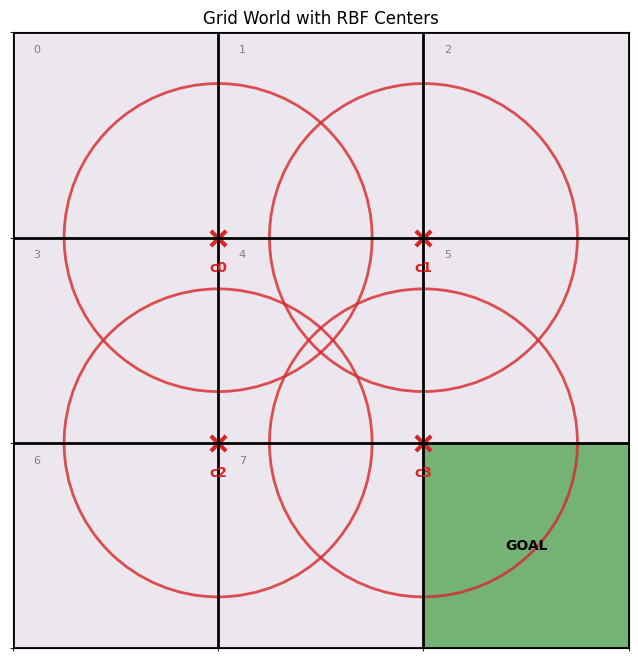

In [54]:
plot_grid_with_rbf(
    grid_size=3,
    centers=centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    terminal_states={goal_grid},
)

With the 5x5 centers is okay and converges having bandwidth at 0.5 but when we move to 4x4 centers.... policy is reasonable only here but is really difficult, if you change a bit the lrs or the bandwidth doesnt take the right action anymore and diverges.

In [70]:
solver_sbeed = SBEEDSolver(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-3,
    lr_policy=1e-3,
    tau=10000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1500,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=1000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1500 buffer=2000 objective=0.045087 primal_mse=0.045324 dual_mse=0.023708 theta_grad=3.651e-02 policy_grad=7.464e-02
episode=100/1500 buffer=3000 objective=0.041905 primal_mse=0.042166 dual_mse=0.026106 theta_grad=2.057e-02 policy_grad=2.645e-02
episode=150/1500 buffer=4000 objective=0.039545 primal_mse=0.039748 dual_mse=0.020304 theta_grad=2.439e-02 policy_grad=5.472e-02
episode=200/1500 buffer=5000 objective=0.039437 primal_mse=0.039639 dual_mse=0.020200 theta_grad=3.018e-02 policy_grad=6.030e-02
episode=250/1500 buffer=6000 objective=0.038933 primal_mse=0.039185 dual_mse=0.025205 theta_grad=2.386e-02 policy_grad=4.563e-02
episode=300/1500 buffer=7000 objective=0.038310 primal_mse=0.038549 dual_mse=0.023939 theta_grad=1.729e-02 policy_grad=3.391e-02
episode=350/1500 buffer=8000 objective=0.037872 primal_mse=0.038055 dual_mse=0.018304 theta_grad=2.035e-02 policy_grad=4.746e-02
episode=400/1500 buffer=9000 objective=0.038530 primal_mse=0.038727 dual_mse=0.019749 theta_grad=1

In [71]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.246  pi(1|0)=0.255  pi(2|0)=0.246  pi(3|0)=0.254  --> best action: 1
State 1: pi(0|1)=0.250  pi(1|1)=0.255  pi(2|1)=0.245  pi(3|1)=0.250  --> best action: 1
State 2: pi(0|2)=0.249  pi(1|2)=0.252  pi(2|2)=0.249  pi(3|2)=0.250  --> best action: 1
State 3: pi(0|3)=0.245  pi(1|3)=0.251  pi(2|3)=0.250  pi(3|3)=0.255  --> best action: 3
State 4: pi(0|4)=0.249  pi(1|4)=0.251  pi(2|4)=0.249  pi(3|4)=0.251  --> best action: 3
State 5: pi(0|5)=0.229  pi(1|5)=0.312  pi(2|5)=0.230  pi(3|5)=0.230  --> best action: 1
State 6: pi(0|6)=0.249  pi(1|6)=0.249  pi(2|6)=0.250  pi(3|6)=0.251  --> best action: 3
State 7: pi(0|7)=0.230  pi(1|7)=0.229  pi(2|7)=0.229  pi(3|7)=0.312  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0




# 5 Grid

## Deterministic

In [72]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1

center_lin = torch.linspace(0.0, 1.0, 4, dtype=torch.float64)

centers = torch.tensor(
    [[r, c] for r in center_lin for c in center_lin],
    dtype=torch.float64,
)


state_coords = torch.tensor(
    [[r / 4.0, c / 4.0] for r in range(5) for c in range(5)],
    dtype=torch.float64,
)

# centers = state_coords.clone()

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.25,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

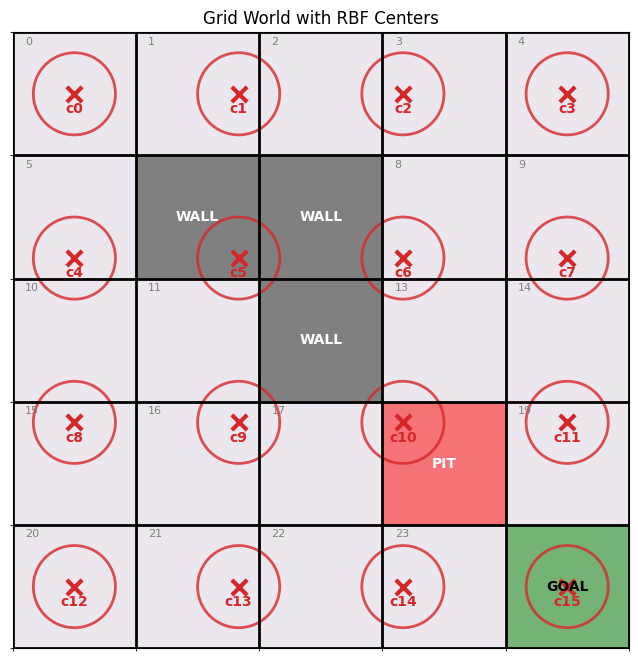

In [73]:
plot_grid_with_rbf(
    grid_size=5,
    centers=centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    pit_grid=pit_grid,        
    wall_states=wall_states, 
    terminal_states={goal_grid, pit_grid},
)

In [80]:
solver_sbeed = SBEEDSolver(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.05,
    ridge=1e-4,
    lr_value=5e-2,
    lr_policy=1.0,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1600,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=500,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states=terminal_states,
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1600 buffer=1500 objective=0.002308 primal_mse=0.007841 dual_mse=0.110668 theta_grad=5.792e-03 policy_grad=1.362e-02
episode=100/1600 buffer=2500 objective=0.001180 primal_mse=0.005258 dual_mse=0.081557 theta_grad=3.365e-03 policy_grad=7.320e-03
episode=150/1600 buffer=3500 objective=0.001461 primal_mse=0.003197 dual_mse=0.034727 theta_grad=6.362e-03 policy_grad=4.348e-03
episode=200/1600 buffer=4500 objective=0.002307 primal_mse=0.002370 dual_mse=0.001259 theta_grad=1.544e-02 policy_grad=6.798e-03
episode=250/1600 buffer=5500 objective=0.001189 primal_mse=0.001607 dual_mse=0.008369 theta_grad=5.500e-03 policy_grad=6.073e-03
episode=300/1600 buffer=6500 objective=0.001357 primal_mse=0.001429 dual_mse=0.001427 theta_grad=4.548e-03 policy_grad=8.744e-03
episode=350/1600 buffer=7500 objective=0.001004 primal_mse=0.001063 dual_mse=0.001185 theta_grad=3.718e-04 policy_grad=4.507e-04
episode=400/1600 buffer=8500 objective=0.000818 primal_mse=0.000862 dual_mse=0.000889 theta_grad=3

In [82]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.249  pi(1|0)=0.251  pi(2|0)=0.248  pi(3|0)=0.252  --> best action: 3
State 1: pi(0|1)=0.248  pi(1|1)=0.248  pi(2|1)=0.244  pi(3|1)=0.260  --> best action: 3
State 2: pi(0|2)=0.253  pi(1|2)=0.253  pi(2|2)=0.240  pi(3|2)=0.255  --> best action: 3
State 3: pi(0|3)=0.243  pi(1|3)=0.266  pi(2|3)=0.242  pi(3|3)=0.249  --> best action: 1
State 4: pi(0|4)=0.243  pi(1|4)=0.278  pi(2|4)=0.237  pi(3|4)=0.242  --> best action: 1
State 5: pi(0|5)=0.244  pi(1|5)=0.262  pi(2|5)=0.247  pi(3|5)=0.247  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.196  pi(1|8)=0.363  pi(2|8)=0.209  pi(3|8)=0.232  --> best action: 1
State 9: pi(0|9)=0.209  pi(1|9)=0.340  pi(2|9)=0.216  pi(3|9)=0.236  --> best action: 1
State 10: pi(0|10)=0.234  pi(1|10)=0.256  pi(2|10)=0.249  pi(3|10)=0.262  --> best 

I had problems with state 22, in those cases is important the bandwidth of the RBF features to be converging to the right action!

## Stochastic

In [83]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

In this case the noise is mucho more noticeable!
Rho update is much more noise, because in the paper we are trying to move rho to the bellman error that is an approximation of the true one, taking out the expectatcion. TAKE OUT THIS EXPECTATION IS THE PROBLEM, becacause in this problem the stochasticity is in the next state, so there will be much more variance on the bellam value so in the rho update.
Solution for now could be using a much bigger batch! With this the variance could be less.

In [95]:
solver_sbeed = SBEEDSolver(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.01,
    ridge=1e-3,

    lr_value=1e-2,

    # Stronger policy update because your current policy barely moves.
    lr_policy=1.0,

    tau=100000.0,

    buffer_mode="fifo",
    max_buffer_size=10000,

    # Full-buffer is stable but slow.
    # Use 1024 to recover speed without going back to noisy 256.
    batch_size=1024,

    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1600,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=500,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states=terminal_states,
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1600 buffer=1500 objective=0.007220 primal_mse=0.007267 dual_mse=0.004656 theta_grad=8.396e-03 policy_grad=3.631e-03
episode=100/1600 buffer=2500 objective=0.008092 primal_mse=0.008156 dual_mse=0.006391 theta_grad=9.551e-03 policy_grad=6.021e-03
episode=150/1600 buffer=3500 objective=0.006445 primal_mse=0.006497 dual_mse=0.005270 theta_grad=6.792e-03 policy_grad=2.305e-03
episode=200/1600 buffer=4500 objective=0.005826 primal_mse=0.005866 dual_mse=0.004022 theta_grad=1.061e-02 policy_grad=4.197e-03
episode=250/1600 buffer=5500 objective=0.005218 primal_mse=0.005292 dual_mse=0.007421 theta_grad=8.709e-03 policy_grad=4.153e-03
episode=300/1600 buffer=6500 objective=0.004801 primal_mse=0.004858 dual_mse=0.005639 theta_grad=7.252e-03 policy_grad=4.152e-03
episode=350/1600 buffer=7500 objective=0.004576 primal_mse=0.004615 dual_mse=0.003844 theta_grad=7.187e-03 policy_grad=3.287e-03
episode=400/1600 buffer=8500 objective=0.004526 primal_mse=0.004563 dual_mse=0.003635 theta_grad=1

With more steps we can get more probabilities to the best actions, but as the batch size is bigger, in cpu takes too much time so we leave it like this.

In [96]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.244  pi(1|0)=0.254  pi(2|0)=0.245  pi(3|0)=0.257  --> best action: 3
State 1: pi(0|1)=0.242  pi(1|1)=0.241  pi(2|1)=0.232  pi(3|1)=0.284  --> best action: 3
State 2: pi(0|2)=0.258  pi(1|2)=0.260  pi(2|2)=0.221  pi(3|2)=0.261  --> best action: 3
State 3: pi(0|3)=0.246  pi(1|3)=0.246  pi(2|3)=0.250  pi(3|3)=0.259  --> best action: 3
State 4: pi(0|4)=0.248  pi(1|4)=0.268  pi(2|4)=0.233  pi(3|4)=0.251  --> best action: 1
State 5: pi(0|5)=0.232  pi(1|5)=0.284  pi(2|5)=0.243  pi(3|5)=0.241  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.222  pi(1|8)=0.294  pi(2|8)=0.225  pi(3|8)=0.259  --> best action: 1
State 9: pi(0|9)=0.220  pi(1|9)=0.306  pi(2|9)=0.225  pi(3|9)=0.249  --> best action: 1
State 10: pi(0|10)=0.218  pi(1|10)=0.250  pi(2|10)=0.261  pi(3|10)=0.270  --> best 